<a href="https://colab.research.google.com/github/khoanguyen31251027416-del/Baitap/blob/main/Logic_Mo_Baitap_2_11_2_14.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 20.7 MB/s eta 0:00:00


--- KẾT QUẢ BÀI 2.11 ---
Giá cước: 81.11 (x1000 VNĐ)
Tiền thưởng tài xế: 84.44 (x1000 VNĐ)


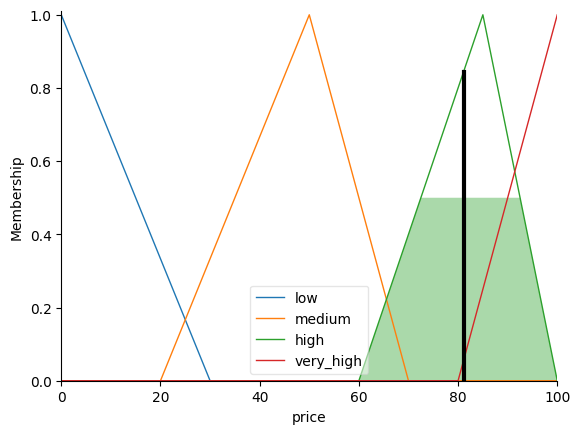

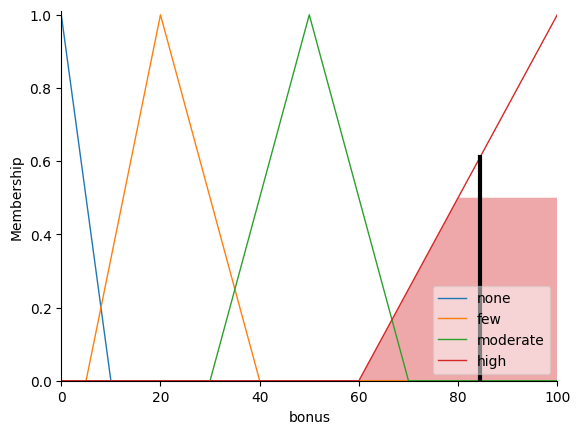

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
distance = ctrl.Antecedent(np.arange(0, 50.1, 0.1), 'distance')
traffic = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'traffic')
demand = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'demand')
weather = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'weather')
rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
punctuality = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'punctuality')
price = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'price')
bonus = ctrl.Consequent(np.arange(0, 100.1, 0.1), 'bonus')
distance['short'] = fuzz.trimf(distance.universe, [0, 0, 3])
distance['medium'] = fuzz.trimf(distance.universe, [2, 5, 8])
distance['long'] = fuzz.trimf(distance.universe, [6, 13, 20])
distance['very_long'] = fuzz.trimf(distance.universe, [15, 50, 50])
traffic['low'] = fuzz.trimf(traffic.universe, [0, 0, 30])
traffic['medium'] = fuzz.trimf(traffic.universe, [20, 50, 70])
traffic['high'] = fuzz.trimf(traffic.universe, [60, 100, 100])
demand['low'] = fuzz.trimf(demand.universe, [0, 0, 30])
demand['medium'] = fuzz.trimf(demand.universe, [20, 50, 70])
demand['high'] = fuzz.trimf(demand.universe, [60, 100, 100])
weather['good'] = fuzz.trimf(weather.universe, [0, 0, 5])
weather['bad'] = fuzz.trimf(weather.universe, [5, 10, 10])
rating['poor'] = fuzz.trimf(rating.universe, [1, 1, 2.5])
rating['average'] = fuzz.trimf(rating.universe, [2, 3, 4])
rating['good'] = fuzz.trimf(rating.universe, [3.5, 5, 5])
punctuality['late'] = fuzz.trimf(punctuality.universe, [0, 0, 50])
punctuality['on_time'] = fuzz.trimf(punctuality.universe, [40, 60, 80])
punctuality['early'] = fuzz.trimf(punctuality.universe, [70, 100, 100])
price['low'] = fuzz.trimf(price.universe, [0, 0, 30])
price['medium'] = fuzz.trimf(price.universe, [20, 50, 70])
price['high'] = fuzz.trimf(price.universe, [60, 85, 100])
price['very_high'] = fuzz.trimf(price.universe, [80, 100, 100])
bonus['none'] = fuzz.trimf(bonus.universe, [0, 0, 10])
bonus['few'] = fuzz.trimf(bonus.universe, [5, 20, 40])
bonus['moderate'] = fuzz.trimf(bonus.universe, [30, 50, 70])
bonus['high'] = fuzz.trimf(bonus.universe, [60, 100, 100])
rule1 = ctrl.Rule(distance['short'] & traffic['low'] & demand['low'], price['low'])
rule2 = ctrl.Rule(distance['short'] & traffic['medium'] & demand['high'], price['medium'])
rule3 = ctrl.Rule(distance['medium'] & traffic['high'] & demand['high'], price['high'])
rule4 = ctrl.Rule(distance['long'] & traffic['medium'] & weather['good'], price['medium'])
rule5 = ctrl.Rule(distance['long'] & traffic['high'] & weather['bad'], price['high'])
rule6 = ctrl.Rule(distance['very_long'] & traffic['high'] & demand['high'], price['very_high'])
rule7 = ctrl.Rule(distance['medium'] & traffic['low'] & demand['low'], price['medium'])
rule8 = ctrl.Rule(distance['short'] & traffic['high'] & demand['high'], price['high'])
rule9 = ctrl.Rule(distance['very_long'] & weather['bad'], price['very_high'])
rule10 = ctrl.Rule(distance['medium'] & traffic['medium'] & weather['good'], price['medium'])
rule11 = ctrl.Rule(rating['good'] & punctuality['early'], bonus['high'])
rule12 = ctrl.Rule(rating['average'] & punctuality['on_time'], bonus['moderate'])
rule13 = ctrl.Rule(rating['poor'] & punctuality['late'], bonus['none'])
rule14 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['on_time'], bonus['high'])
rule15 = ctrl.Rule(distance['medium'] & traffic['medium'] & rating['good'], bonus['moderate'])
rule16 = ctrl.Rule(rating['poor'] & punctuality['late'], bonus['none']) # Lặp lại rule 13 như trong ảnh
rule17 = ctrl.Rule(distance['very_long'] & weather['bad'] & rating['good'], bonus['high'])
rule18 = ctrl.Rule(distance['short'] & rating['average'] & punctuality['on_time'], bonus['few'])
rule19 = ctrl.Rule(distance['long'] & traffic['high'] & punctuality['late'], bonus['few'])
rule20 = ctrl.Rule(distance['medium'] & demand['medium'] & rating['good'], bonus['moderate']) # Đã sửa: Nhu cầu trung bình
grab_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7, rule8, rule9, rule10,
                                rule11, rule12, rule13, rule14, rule15, rule16, rule17, rule18, rule19, rule20])
grab_sim = ctrl.ControlSystemSimulation(grab_ctrl)
grab_sim.input['distance'] = 10.0
grab_sim.input['traffic'] = 80.0
grab_sim.input['demand'] = 90.0
grab_sim.input['weather'] = 8.0
grab_sim.input['rating'] = 4.5
grab_sim.input['punctuality'] = 60.0
grab_sim.compute()
print(f"--- KẾT QUẢ BÀI 2.11 ---")
print(f"Giá cước: {grab_sim.output['price']:.2f} (x1000 VNĐ)")
print(f"Tiền thưởng tài xế: {grab_sim.output['bonus']:.2f} (x1000 VNĐ)")
price.view(sim=grab_sim)
bonus.view(sim=grab_sim)

--- KẾT QUẢ BÀI 2.12 ---
Mức chiết khấu đề xuất: 46.06%


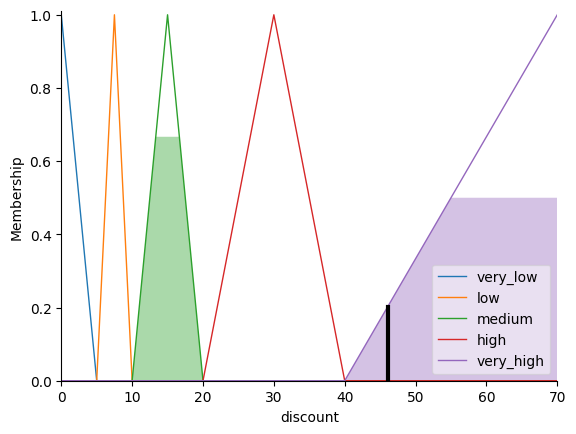

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
rating = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'rating')
sales = ctrl.Antecedent(np.arange(0, 1001, 1), 'sales')
profit = ctrl.Antecedent(np.arange(0, 101, 1), 'profit')
season = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'season')
competitor = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'competitor')
discount = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount')
rating['low'] = fuzz.trimf(rating.universe, [1, 1, 4])
rating['medium'] = fuzz.trimf(rating.universe, [4, 4.25, 4.5])
rating['high'] = fuzz.trimf(rating.universe, [4.5, 5, 5])
sales['low'] = fuzz.trimf(sales.universe, [0, 0, 300])
sales['medium'] = fuzz.trimf(sales.universe, [200, 500, 800])
sales['high'] = fuzz.trimf(sales.universe, [700, 1000, 1000])
profit['low'] = fuzz.trimf(profit.universe, [0, 0, 20])
profit['medium'] = fuzz.trimf(profit.universe, [15, 30, 50])
profit['high'] = fuzz.trimf(profit.universe, [40, 100, 100])
season['none'] = fuzz.trimf(season.universe, [0, 0, 3])
season['medium'] = fuzz.trimf(season.universe, [2, 5, 8])
season['high'] = fuzz.trimf(season.universe, [7, 10, 10])
competitor['low'] = fuzz.trimf(competitor.universe, [0, 0, 5])
competitor['medium'] = fuzz.trimf(competitor.universe, [3, 5, 7])
competitor['high'] = fuzz.trimf(competitor.universe, [6, 10, 10])
discount['very_low'] = fuzz.trimf(discount.universe, [0, 0, 5])
discount['low'] = fuzz.trimf(discount.universe, [5, 7.5, 10])
discount['medium'] = fuzz.trimf(discount.universe, [10, 15, 20])
discount['high'] = fuzz.trimf(discount.universe, [20, 30, 40])
discount['very_high'] = fuzz.trimf(discount.universe, [40, 70, 70])
rule1 = ctrl.Rule(rating['high'] & sales['high'] & profit['high'], discount['very_low'])
rule2 = ctrl.Rule(rating['low'] & sales['low'] & profit['high'], discount['high'])
rule3 = ctrl.Rule(season['high'] & competitor['high'], discount['very_high'])
rule4 = ctrl.Rule(rating['medium'] & sales['medium'] & profit['medium'], discount['medium'])
rule5 = ctrl.Rule(competitor['low'] & profit['low'] & sales['high'], discount['very_low'])
rule6 = ctrl.Rule(rating['low'] & season['none'], discount['medium'])
rule7 = ctrl.Rule(sales['low'] & profit['low'], discount['very_high'])
shopee_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
shopee_sim = ctrl.ControlSystemSimulation(shopee_ctrl)
shopee_sim.input['rating'] = 2.0
shopee_sim.input['sales'] = 100.0
shopee_sim.input['profit'] = 10.0
shopee_sim.input['season'] = 1.0
shopee_sim.input['competitor'] = 2.0
shopee_sim.compute()
print(f"--- KẾT QUẢ BÀI 2.12 ---")
print(f"Mức chiết khấu đề xuất: {shopee_sim.output['discount']:.2f}%")
discount.view(sim=shopee_sim)

--- KẾT QUẢ BÀI 2.13 ---
Mức chiết khấu sản phẩm đề xuất: 55.00%


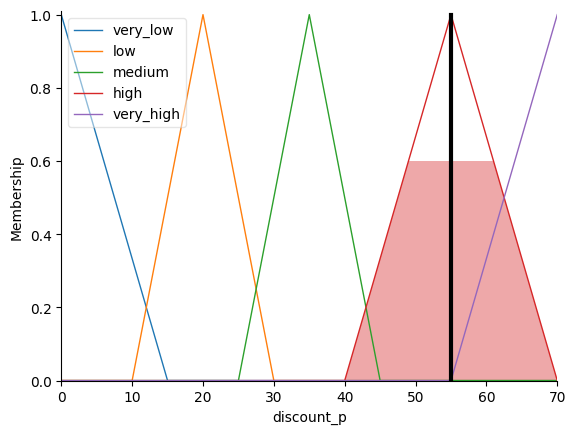

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
demand_p = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'demand_p')
pressure = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'pressure')
reputation = ctrl.Antecedent(np.arange(1, 5.1, 0.1), 'reputation')
margin = ctrl.Antecedent(np.arange(0, 100.1, 0.1), 'margin')
seasonal = ctrl.Antecedent(np.arange(0, 10.1, 0.1), 'seasonal')
discount_p = ctrl.Consequent(np.arange(0, 70.1, 0.1), 'discount_p')
demand_p['low'] = fuzz.trimf(demand_p.universe, [0, 0, 5])
demand_p['medium'] = fuzz.trimf(demand_p.universe, [2, 5, 8])
demand_p['high'] = fuzz.trimf(demand_p.universe, [5, 10, 10])
pressure['low'] = fuzz.trimf(pressure.universe, [0, 0, 5])
pressure['medium'] = fuzz.trimf(pressure.universe, [3, 5, 7])
pressure['high'] = fuzz.trimf(pressure.universe, [6, 10, 10])
reputation['low'] = fuzz.trimf(reputation.universe, [1, 1, 3])
reputation['medium'] = fuzz.trimf(reputation.universe, [2, 3, 4])
reputation['high'] = fuzz.trimf(reputation.universe, [3.5, 5, 5])
margin['low'] = fuzz.trimf(margin.universe, [0, 0, 40])
margin['medium'] = fuzz.trimf(margin.universe, [20, 50, 80])
margin['high'] = fuzz.trimf(margin.universe, [60, 100, 100])
seasonal['none'] = fuzz.trimf(seasonal.universe, [0, 0, 3])
seasonal['medium'] = fuzz.trimf(seasonal.universe, [2, 5, 8])
seasonal['high'] = fuzz.trimf(seasonal.universe, [7, 10, 10])
discount_p['very_low'] = fuzz.trimf(discount_p.universe, [0, 0, 15])
discount_p['low'] = fuzz.trimf(discount_p.universe, [10, 20, 30])
discount_p['medium'] = fuzz.trimf(discount_p.universe, [25, 35, 45])
discount_p['high'] = fuzz.trimf(discount_p.universe, [40, 55, 70])
discount_p['very_high'] = fuzz.trimf(discount_p.universe, [55, 70, 70])
rule1 = ctrl.Rule(demand_p['high'] & pressure['low'] & margin['low'], discount_p['very_low'])
rule2 = ctrl.Rule(demand_p['low'] & pressure['high'] & margin['high'], discount_p['high'])
rule3 = ctrl.Rule(reputation['high'] & margin['medium'] & seasonal['high'], discount_p['medium'])
rule4 = ctrl.Rule(pressure['high'] & seasonal['high'] & margin['high'], discount_p['very_high'])
rule5 = ctrl.Rule(reputation['low'] & demand_p['medium'] & margin['low'], discount_p['medium'])
rule6 = ctrl.Rule(demand_p['high'] & seasonal['none'] & pressure['low'], discount_p['very_low'])
rule7 = ctrl.Rule(margin['high'] & pressure['medium'] & seasonal['medium'], discount_p['medium'])
strategy_ctrl = ctrl.ControlSystem([rule1, rule2, rule3, rule4, rule5, rule6, rule7])
strategy_sim = ctrl.ControlSystemSimulation(strategy_ctrl)
strategy_sim.input['demand_p'] = 2.0
strategy_sim.input['pressure'] = 8.5
strategy_sim.input['reputation'] = 4.0
strategy_sim.input['margin'] = 90.0
strategy_sim.input['seasonal'] = 1.0
strategy_sim.compute()
print(f"--- KẾT QUẢ BÀI 2.13 ---")
print(f"Mức chiết khấu sản phẩm đề xuất: {strategy_sim.output['discount_p']:.2f}%")
discount_p.view(sim=strategy_sim)

--- KẾT QUẢ BÀI 2.14 ---
Số lượng đơn hàng kết hợp: 8.51
Mức độ ưu tiên giao hàng: 7.96


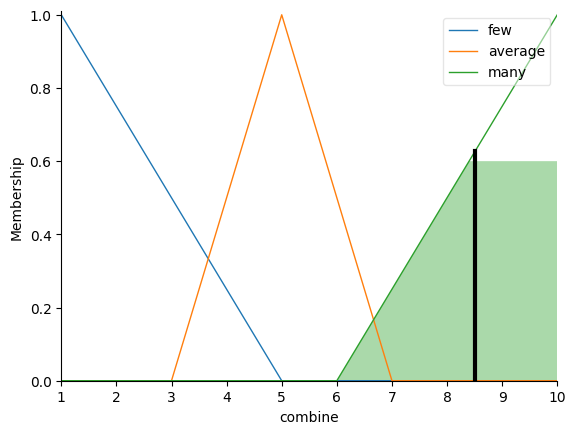

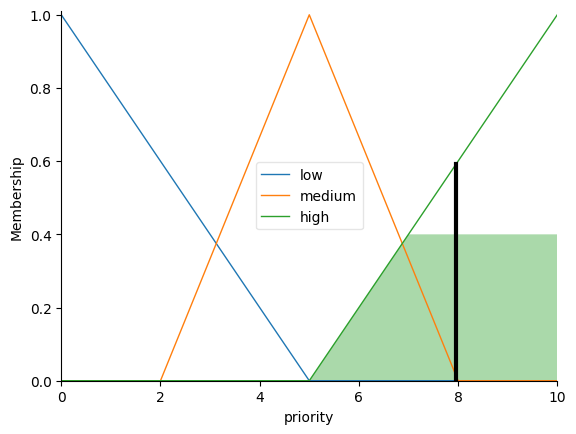

In [ ]:
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import numpy as np
density = ctrl.Antecedent(np.arange(0, 11, 1), 'density')
urgency = ctrl.Antecedent(np.arange(0, 11, 1), 'urgency')
load = ctrl.Antecedent(np.arange(0, 11, 1), 'load')
traffic = ctrl.Antecedent(np.arange(0, 11, 1), 'traffic')
profit = ctrl.Antecedent(np.arange(0, 11, 1), 'profit')
combine = ctrl.Consequent(np.arange(1, 11, 1), 'combine')
priority = ctrl.Consequent(np.arange(0, 11, 1), 'priority')
for var in [density, urgency, load, profit]:
    var['low'] = fuzz.trimf(var.universe, [0, 0, 5])
    var['medium'] = fuzz.trimf(var.universe, [2, 5, 8])
    var['high'] = fuzz.trimf(var.universe, [5, 10, 10])
traffic['good'] = fuzz.trimf(traffic.universe, [0, 0, 5])
traffic['medium'] = fuzz.trimf(traffic.universe, [2, 5, 8])
traffic['bad'] = fuzz.trimf(traffic.universe, [5, 10, 10])
combine['few'] = fuzz.trimf(combine.universe, [1, 1, 5])
combine['average'] = fuzz.trimf(combine.universe, [3, 5, 7])
combine['many'] = fuzz.trimf(combine.universe, [6, 10, 10])
priority['low'] = fuzz.trimf(priority.universe, [0, 0, 5])
priority['medium'] = fuzz.trimf(priority.universe, [2, 5, 8])
priority['high'] = fuzz.trimf(priority.universe, [5, 10, 10])
rules_logistics = [
    ctrl.Rule(density['high'] & load['low'] & traffic['good'], combine['many']),
    ctrl.Rule(density['medium'] & traffic['bad'] & urgency['medium'], combine['average']),
    ctrl.Rule(load['high'] & density['high'] & profit['medium'], combine['average']),
    ctrl.Rule(density['low'] & urgency['high'] & traffic['medium'], combine['average']),
    ctrl.Rule(profit['high'] & urgency['high'] & traffic['bad'], combine['average']),
    ctrl.Rule(urgency['high'] & profit['high'], priority['high']),
    ctrl.Rule(urgency['medium'] & traffic['medium'], priority['medium']),
    ctrl.Rule(urgency['low'] & density['high'] & profit['low'], priority['low'])
]
logistics_ctrl = ctrl.ControlSystem(rules_logistics)
logistics_sim = ctrl.ControlSystemSimulation(logistics_ctrl)
logistics_sim.input['density'] = 9.0
logistics_sim.input['urgency'] = 8.0
logistics_sim.input['load'] = 2.0
logistics_sim.input['traffic'] = 1.0
logistics_sim.input['profit'] = 7.0
logistics_sim.compute()
print(f"--- KẾT QUẢ BÀI 2.14 ---")
print(f"Số lượng đơn hàng kết hợp: {logistics_sim.output['combine']:.2f}")
print(f"Mức độ ưu tiên giao hàng: {logistics_sim.output['priority']:.2f}")
combine.view(sim=logistics_sim)
priority.view(sim=logistics_sim)